In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 5.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
!pip install xgboost==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 41.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [9]:
!pip install lightgbm==4.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [13]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


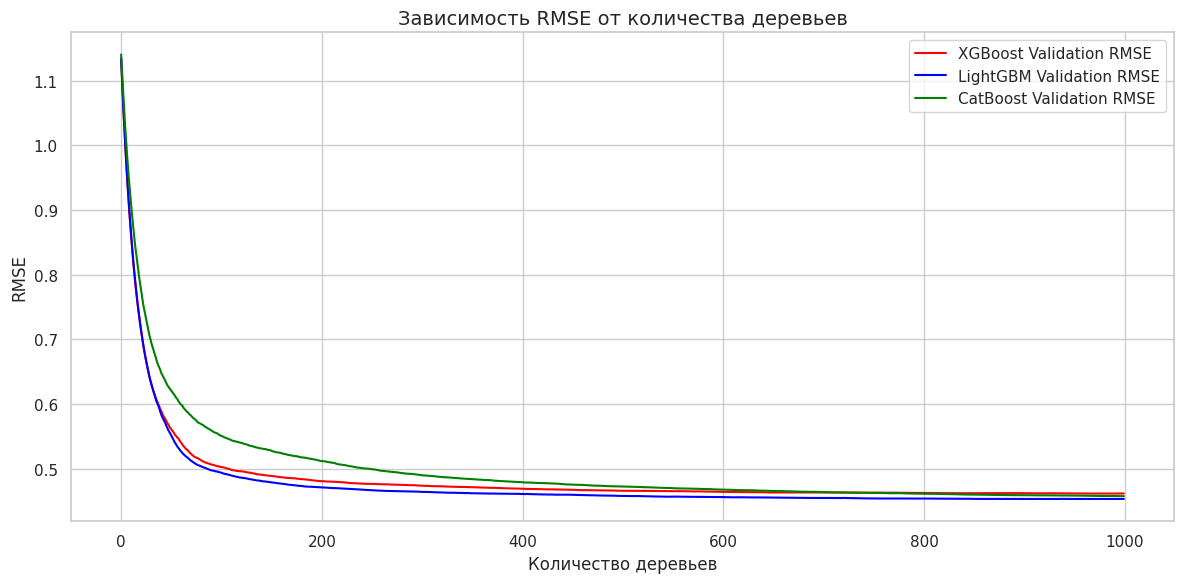

In [15]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
SELECTED_N_ESTIMATORS = 400

In [19]:
class MyBoost:
  def __init__(self, n=400, lr=0.05, depth=7, seed=42) -> None:
      self.n = n
      self.lr = lr
      self.depth = depth
      self.seed = seed
      self.trees = []

  def fit(self, X, y):
    self.initial_leaf = y.mean()
    predictions = np.zeros(len(y)) + self.initial_leaf

    for _ in range(self.n):
      antigrad = y - predictions
      tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")
        
      tree.fit(X, antigrad)
      self.trees.append(tree)

      predictions += tree.predict(X) * self.lr

  def predict(self, samples):
    predictions = np.zeros(len(samples)) + self.initial_leaf
    for i in range(self.n):
      predictions += self.lr * self.trees[i].predict(samples)

    return predictions


In [21]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4621
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [51]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost()
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,0.742,0.2912,0.4476,0.8471
1,LightGBM,0.304,0.2862,0.4379,0.8537
2,CatBoost,14.428,0.2967,0.4493,0.8460
3,MyBoost,26.682,0.2955,0.4564,0.8410


### Домашнее задание

Внизу реализован Регрессор, где есть идея подмножеств строк, столбцов и feature_importance_. А тут ещё я перешла к numpy, чтобы было быстрее, чем с Pandas. Что было сделано в совокупности:
- добавлена поддержка subsample (подмножества строк) для избегания переобучения и подмножеств столбцов
- feature_importance_ как усреднение по всем деревьям в бустинге и также стандартизирование.
- нативная поддержка категориальных признаков, как это реализовано light gbm (target_encoding на обучающей выборке)

In [53]:
class MyBoostRegressor:
    def __init__(
        self,
        n=500,
        lr=0.05,
        depth=7,
        seed=42,
        subsample=0.8,
        colsample_tree=0.6
    ) -> None:

        self.n = n
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.trees = []
        self.features = []
        self.all_features = []
        self.cat_encoding = {}
        self.subsample = subsample
        self.colsample_tree = colsample_tree
        # глобальное среднее по таргету
        self.global_mean = None

    def categorical_encoding(self, X, y=None):
        X = X.copy()
        cat_columns = X.select_dtypes(
            include=['object']
        ).columns

        # обучение енкодера в fit
        if y is not None:
            self.global_mean = y.mean()
            for col in cat_columns:
                col_encoding = {}
                for value in X[col].unique():
                    col_encoding[value] = (
                        y[X[col] == value].mean()
                    )

                self.cat_encoding[col] = col_encoding

        # применение target encoding
        for col in cat_columns:
            # если категории нет — fill global mean
            X['cat_' + col] = (
                X[col]
                .map(self.cat_encoding[col])
                .fillna(self.global_mean)
            )

        X = X.drop(columns=cat_columns)

        return X

    def fit(self, X, y):
        X = self.categorical_encoding(X, y)
        self.all_features = X.columns
        self.trees = []
        self.features = []
        N = X.shape[0]
        D = X.shape[1]
        X = np.array(X)
        y = np.array(y)
        self.initial_leaf = y.mean()
        predictions = np.full(
            len(y),
            self.initial_leaf
        )

        rng = np.random.RandomState(self.seed)
        for i in range(self.n):
            rows = rng.choice(
                N,
                int(N * self.subsample),
                replace=False
            )
            antigrad = (
                y[rows] - predictions[rows]
            )
            X_train = X[rows]
            cols_idx = rng.choice(
                D,
                max(1, int(D * self.colsample_tree)),
                replace=False
            )
            X_train = X_train[:, cols_idx]
            tree = DecisionTreeRegressor(
                max_depth=self.depth,
                random_state=self.seed + i,
                criterion="friedman_mse"
            )
            tree.fit(X_train, antigrad)
            self.features.append(cols_idx)
            self.trees.append(tree)
            predictions += (
                tree.predict(X[:, cols_idx]) * self.lr
            )

    def predict(self, samples):
        samples = self.categorical_encoding(samples)
        samples = np.array(samples)
        predictions = (
            np.zeros(len(samples)) + self.initial_leaf
        )
        for i in range(self.n):
            cols_idx = self.features[i]
            predictions += (
                self.lr *
                self.trees[i].predict(
                    samples[:, cols_idx]
                )
            )

        return predictions

    @property
    def feature_importances_(self):
        if not self.trees:
            raise ValueError("Model not fitted")
        global_feature_importances_ = np.zeros(
            len(self.all_features),
            dtype=float
        )
        for tree, cols_idx in zip(
            self.trees,
            self.features
        ):
            global_feature_importances_[cols_idx] += (
                self.lr *
                tree.feature_importances_
            )
        global_feature_importances_ /= len(self.trees)
        total = global_feature_importances_.sum()
        if total != 0:
            global_feature_importances_ /= total

        return global_feature_importances_

Внизу проведем снова обучение, чтобы сравнить мою новую модель с остальными

In [55]:
model = MyBoostRegressor()
start_time = time.time()
model.fit(X_train_full, y_train_full)
train_time = time.time() - start_time

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

results.append({
    "Модель": 'MyBoostRegressor',
    "Время обучения": round(train_time, 3),
    "MAE": round(mae, 4),
    "RMSE": round(rmse, 4),
    "R2 Score": round(r2, 4)
})
df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,0.742,0.2912,0.4476,0.8471
1,LightGBM,0.304,0.2862,0.4379,0.8537
2,CatBoost,14.428,0.2967,0.4493,0.8460
3,MyBoost,26.682,0.2955,0.4564,0.8410
4,MyBoostRegressor,13.720,0.2936,0.4464,0.8479


Время уменьшилось по сравнению с MyBoost (из-за сокращения количества строк и колонок ). Метрики немного даже улучшились.

In [ ]:
class MyBoostClassifier:
    def __init__(
        self,
        n=500,
        lr=0.05,
        depth=7,
        seed=42,
        subsample=0.8,
        colsample_tree=0.6,
        threshold=0.5
    ) -> None:

        self.n = n
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.trees = []
        self.features = []
        self.all_features = []
        self.cat_encoding = {}
        self.subsample = subsample
        self.colsample_tree = colsample_tree
        # глобальное среднее по таргету
        self.global_mean = None
        self.threshold = threshold

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def categorical_encoding(self, X, y=None):
        X = X.copy()
        cat_columns = X.select_dtypes(
            include=['object']
        ).columns

        # обучение енкодера в fit
        if y is not None:
            self.global_mean = y.mean()
            for col in cat_columns:
                col_encoding = {}
                for value in X[col].unique():
                    col_encoding[value] = (
                        y[X[col] == value].mean()
                    )

                self.cat_encoding[col] = col_encoding

        # применение target encoding
        for col in cat_columns:
            # если категории нет — fill global mean
            X['cat_' + col] = (
                X[col]
                .map(self.cat_encoding[col])
                .fillna(self.global_mean)
            )

        X = X.drop(columns=cat_columns)

        return X

    def fit(self, X, y):
        X = self.categorical_encoding(X, y)
        self.all_features = X.columns
        self.trees = []
        self.features = []
        N = X.shape[0]
        D = X.shape[1]
        X = np.array(X)
        y = np.array(y)
        #первоначальный p это просто глобальное среднее
        p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.initial_leaf = np.log(p / (1 - p))
        predictions = np.full(
            len(y),
            self.initial_leaf
        )

        rng = np.random.RandomState(self.seed)
        for i in range(self.n):
            rows = rng.choice(
                N,
                int(N * self.subsample),
                replace=False
            )
            p = self.sigmoid(predictions)
            antigrad = y - p
            X_train = X[rows]
            cols_idx = rng.choice(
                D,
                max(1, int(D * self.colsample_tree)),
                replace=False
            )
            X_train = X_train[:, cols_idx]
            tree = DecisionTreeRegressor(
                max_depth=self.depth,
                random_state=self.seed + i,
                criterion="friedman_mse"
            )
            tree.fit(X_train, antigrad)
            self.features.append(cols_idx)
            self.trees.append(tree)
            predictions += (
                tree.predict(X[:, cols_idx]) * self.lr
            )

    def predict_proba(self, samples):
        samples = self.categorical_encoding(samples)
        samples = np.array(samples)
        predictions = (
            np.zeros(len(samples)) + self.initial_leaf
        )
        for i in range(self.n):
            cols_idx = self.features[i]
            predictions += (
                self.lr *
                self.trees[i].predict(
                    samples[:, cols_idx]
                )
            )

        return self.sigmoid(predictions)

    def predict(self, samples):
        probas = self.predict_proba(samples)
        return (probas >= threshold).astype(int)

    @property
    def feature_importances_(self):
        if not self.trees:
            raise ValueError("Model not fitted")
        global_feature_importances_ = np.zeros(
            len(self.all_features),
            dtype=float
        )
        for tree, cols_idx in zip(
            self.trees,
            self.features
        ):
            global_feature_importances_[cols_idx] += (
                self.lr *
                tree.feature_importances_
            )
        global_feature_importances_ /= len(self.trees)
        total = global_feature_importances_.sum()
        if total != 0:
            global_feature_importances_ /= total

        return global_feature_importances_